In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/digit-recognizer/sample_submission.csv
/kaggle/input/digit-recognizer/train.csv
/kaggle/input/digit-recognizer/test.csv


# Digit Recognizer - Utkarsh Gaikwad

# Read the dataset

In [2]:
from warnings import filterwarnings
filterwarnings('ignore')

In [3]:
import pandas as pd
tr = pd.read_csv('/kaggle/input/digit-recognizer/train.csv')
ts = pd.read_csv('/kaggle/input/digit-recognizer/test.csv')

In [4]:
tr.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
ts.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


# Defining X and Y

In [6]:
X = tr.drop(labels=['label'],axis=1)
Y = tr[['label']]

# Plotting a sample image

In [7]:
imgx = X.iloc[0,:].values.reshape(28,28)
imgx

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0, 188, 255,  94,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0, 191, 250, 253,  93,   0,   0,   0,
          0,   0],
       [  

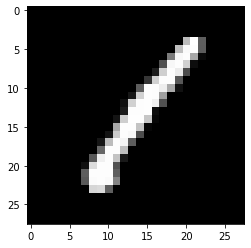

In [8]:
import matplotlib.pyplot as plt
plt.imshow(imgx,cmap='gray')

# Showing 9 sample image from data

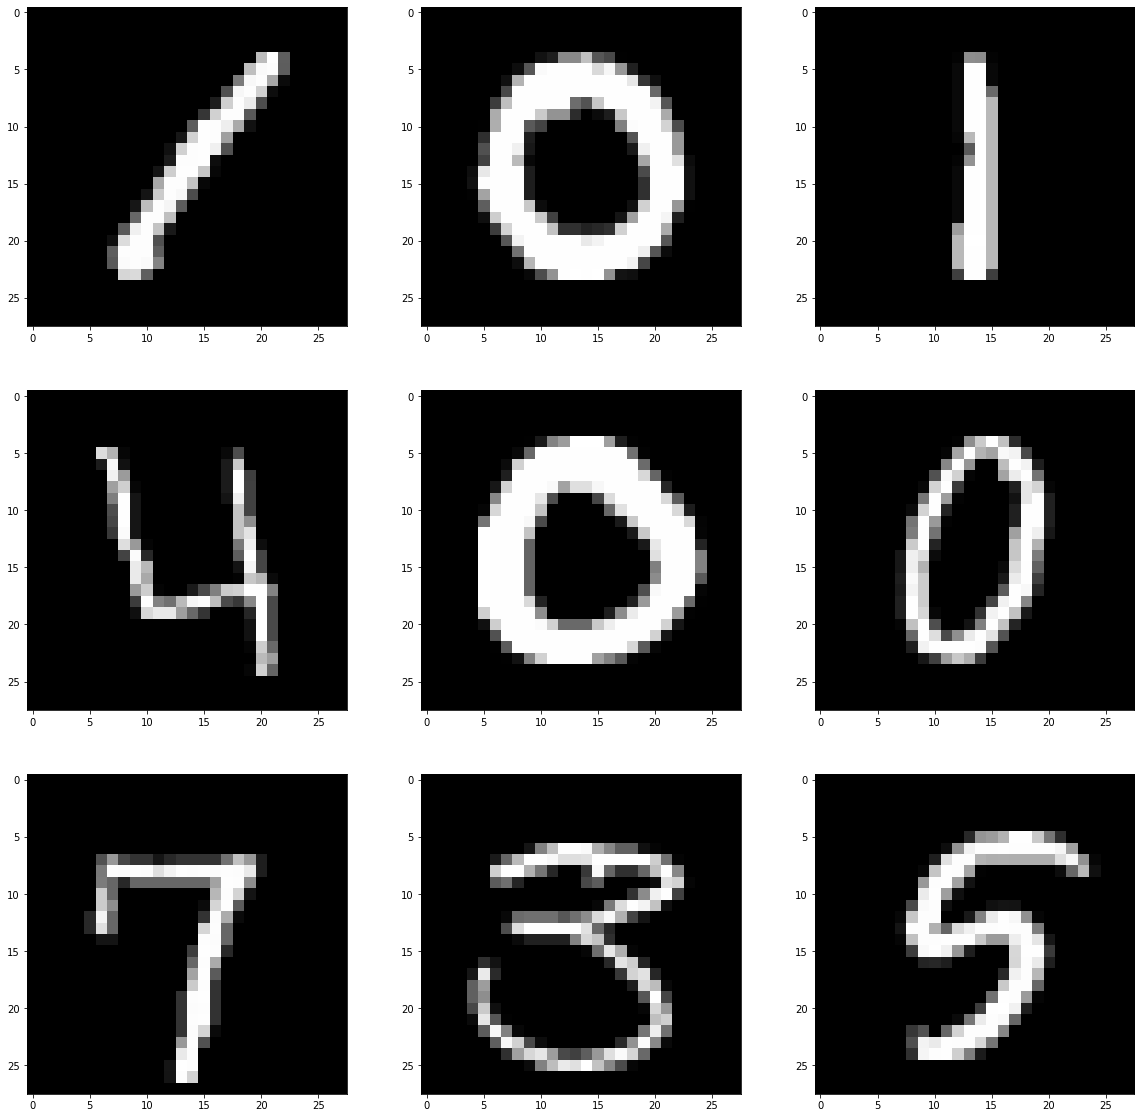

In [9]:
plt.figure(figsize=(20,20))
x = 1
for i in range(9):
    img = X.iloc[i,:].values.reshape(28,28)
    plt.subplot(3,3,x)
    plt.imshow(img,cmap='gray')
    x = x+1
plt.show()

# Data Pre-processing

In [10]:
x = []
for i in range(len(X)):
    img = X.iloc[i,:].values.reshape(28,28)
    x.append(img)
import numpy as np
x = np.array(x)
x = x/255

In [11]:
x[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [12]:
Ynew = pd.get_dummies(Y['label'])
Ynew.head()

,0,1,2,3,4,5,6,7,8,9
0,0,1,0,0,0,0,0,0,0,0
1,1,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0
4,1,0,0,0,0,0,0,0,0,0


# Train Test Split of Data

In [13]:
from sklearn.model_selection import train_test_split
xtrain, xtest, ytrain, ytest = train_test_split(x,Ynew,test_size=0.2, random_state=21,stratify=Ynew)

In [14]:
xtrain = xtrain.reshape(-1,28,28,1)
xtest = xtest.reshape(-1,28,28,1)

# Creating a Convolutional Neural Network

In [15]:
from keras.models import Sequential
from keras.layers import Dense, Convolution2D, MaxPooling2D, BatchNormalization, Dropout, Flatten

In [16]:
nn = Sequential()
nn.add(Convolution2D(filters=16,kernel_size=(3,3),input_shape=(28,28,1)))
nn.add(MaxPooling2D(pool_size=(2,2)))
nn.add(BatchNormalization())
nn.add(Dropout(0.2))

nn.add(Convolution2D(filters=16,kernel_size=(3,3)))
nn.add(MaxPooling2D(pool_size=(2,2)))
nn.add(BatchNormalization())
nn.add(Dropout(0.2))

nn.add(Flatten())
nn.add(Dense(128,activation='relu'))
nn.add(Dropout(0.2))
nn.add(Dense(128,activation='relu'))
nn.add(Dropout(0.2))
nn.add(Dense(10,activation='softmax'))

2022-12-12 15:45:04.261098: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [17]:
nn.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 16)        160       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 16)        0         
_________________________________________________________________
batch_normalization (BatchNo (None, 13, 13, 16)        64        
_________________________________________________________________
dropout (Dropout)            (None, 13, 13, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 16)        2320      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 16)          0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 5, 5, 16)          6

In [18]:
nn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
nn.fit(xtrain,ytrain,batch_size=64,epochs=5,validation_data=(xtest,ytest))

2022-12-12 15:45:04.772597: I tensorflow/compiler/mlir/mlir_graph_optimization_pass.cc:185] None of the MLIR Optimization Passes are enabled (registered 2)


Epoch 1/5
525/525 [==============================] - 8s 14ms/step - loss: 0.4404 - accuracy: 0.8607 - val_loss: 0.1495 - val_accuracy: 0.9551
Epoch 2/5
525/525 [==============================] - 7s 13ms/step - loss: 0.1499 - accuracy: 0.9537 - val_loss: 0.0768 - val_accuracy: 0.9755
Epoch 3/5
525/525 [==============================] - 6s 12ms/step - loss: 0.1136 - accuracy: 0.9648 - val_loss: 0.0512 - val_accuracy: 0.9849
Epoch 4/5
525/525 [==============================] - 6s 12ms/step - loss: 0.0944 - accuracy: 0.9702 - val_loss: 0.0526 - val_accuracy: 0.9835
Epoch 5/5
525/525 [==============================] - 7s 13ms/step - loss: 0.0826 - accuracy: 0.9750 - val_loss: 0.0467 - val_accuracy: 0.9860


# Predicting for Test Dataset

In [19]:
xts = []
for i in range(len(ts)):
    im = ts.iloc[i,:].values.reshape(28,28)
    xts.append(im)
xts = np.array(xts)
xts = xts/255

In [20]:
xts = xts.reshape(-1,28,28,1)

In [21]:
pred = nn.predict(xts)

In [22]:
pred_list = pred.argmax(-1)
pred_list

array([2, 0, 9, ..., 3, 9, 2])

# Saving Predictions in DataFrame

In [23]:
df_pred = pd.DataFrame({'ImageId':range(1,len(ts)+1), 'Label':pred_list})

In [24]:
df_pred

,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,9
4,5,3
...,...,...
27995,27996,9
27996,27997,7
27997,27998,3
27998,27999,9


In [25]:
df_pred.to_csv('/kaggle/working/submission.csv',index=False)